# Variant 1 item distribution

Item spawn counts across the same 100 Variant 1 validation episodes.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'statistic' else NOTEBOOK_DIR
DATA_DIR = PROJECT_ROOT / 'data'
VARIANT = 1
NUM_VALIDATION_EPISODES = 100

episode_ids = pd.read_csv(
    DATA_DIR / 'variant_1' / 'validation_episodes.csv'
)["validation_episodes"].head(NUM_VALIDATION_EPISODES).astype(int).tolist()

assert len(episode_ids) == NUM_VALIDATION_EPISODES
print(f'Validation episodes: {len(episode_ids)}')

Validation episodes: 100


In [2]:
item_spawn_counts = np.zeros((5, 5), dtype=np.int64)

for episode_id in episode_ids:
    episode_data = pd.read_csv(
        DATA_DIR / 'variant_1' / 'episode_data' / f'episode_{episode_id:03d}.csv',
        index_col=0,
    )
    for row, col in zip(episode_data['vertical_idx'], episode_data['horizontal_idx']):
        item_spawn_counts[int(row), int(col)] += 1

print(f'Total item spawns: {item_spawn_counts.sum():,}')

Total item spawns: 4,866


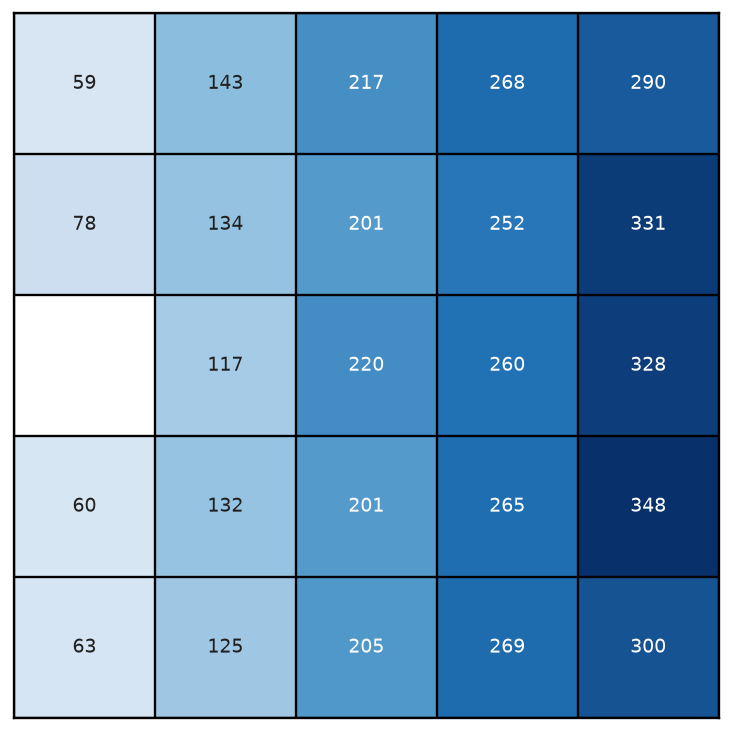

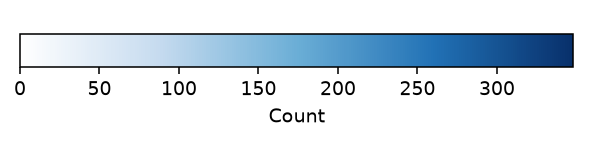

In [3]:
blue_cmap = LinearSegmentedColormap.from_list(
    'count_blue', ['#ffffff', '#c6dbef', '#6baed6', '#2171b5', '#08306b']
)
vmax = int(item_spawn_counts.max())

fig, ax = plt.subplots(figsize=(5.2, 5.2), dpi=140)
ax.imshow(
    item_spawn_counts, cmap=blue_cmap, vmin=0, vmax=vmax,
    interpolation='nearest',
)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticks(np.arange(-0.5, 5, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 5, 1), minor=True)
ax.grid(which='minor', color='black', linewidth=1.2)
ax.tick_params(which='both', bottom=False, left=False)
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.2)

for row in range(5):
    for col in range(5):
        value = int(item_spawn_counts[row, col])
        if value == 0:
            continue
        text_color = 'white' if value > 0.48 * vmax else '#202020'
        ax.text(
            col, row, f'{value:,}', ha='center', va='center',
            color=text_color, fontsize=10,
        )

fig.tight_layout(pad=0.6)
plt.show()

# Standalone legend.
legend_fig, legend_ax = plt.subplots(figsize=(5.2, 1.05), dpi=140)
legend_ax.set_axis_off()
colorbar_ax = legend_fig.add_axes([0.12, 0.52, 0.76, 0.22])
mappable = plt.cm.ScalarMappable(
    norm=plt.Normalize(vmin=0, vmax=vmax), cmap=blue_cmap
)
colorbar = legend_fig.colorbar(mappable, cax=colorbar_ax, orientation='horizontal')
colorbar.set_label('Count')
plt.show()